# Synchronization Analysis With Recurrence Plots

We are looking for a time series which shows generalized synchronization of the form $x(t) = F(y(t))$

The model defined here always has a driver and a response system. You can define if you want to couple the same system with different initial conditions such as two Roessler or Lorenz systems or use one as the driver and one as response. For the standard example I used a Roessler as driver and Lorenz as response

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.spatial.distance import pdist, squareform, cdist

from tqdm import tqdm

# we can use the pyunicorn classes for all types of recurrence plots for convenience
from pyunicorn.timeseries.recurrence_plot import RecurrencePlot
from pyunicorn.timeseries.cross_recurrence_plot import CrossRecurrencePlot
from pyunicorn.timeseries.joint_recurrence_plot import JointRecurrencePlot

In [2]:
def coupled_system(t, state, driver="roessler", response="lorenz", 
                   a=0.2, b=0.2, c=5.7,
                   sigma=10, rho=28, beta=8/3, eps=0.1,
                   synch=["x", "y", "z"],
                   g=None):
    '''
    g : Functional Relationship between driver and response system (python function)
    '''

    if g is None:
          def g(x):
                return x

    x1, y1, z1, x2, y2, z2 = state

    if driver == "roessler":
        dx1 = -(y1 + z1)
        dy1 = x1 + a * y1
        dz1 = b + (x1 - c) * z1

        if response == "lorenz":
                dx2 = sigma * (y2 - x2) + eps * g(x1) if "x" in synch else sigma * (y2 - x2) 
                dy2 = x2 * (rho - z2) - y2 + eps * g(y1) if "y" in synch else x2 * (rho - z2) - y2
                dz2 = x2 * y2 - beta * z2 + eps * g(z1) if "z" in synch else x2 * y2 - beta * z2
        elif response == "roessler":
                dx2 = -(y2 + z2) + eps * g(x1) if "x" in synch else -(y2 + z2)
                dy2 = x2 + a * y2 + eps * g(y1) if "y" in synch else x2 + a * y2
                dz2 = b + (x2 - c) * z2 + eps * g(z1) if "z" in synch else b + (x2 - c) * z2
    
    elif driver == "lorenz":
        dx1 = sigma * (y1 - x1)
        dy1 = x1 * (rho - z1) - y1
        dz1 = x1 * y1 - beta * z1

        if response == "lorenz":
                dx2 = sigma * (y2 - x2) + eps * g(x1) if "x" in synch else sigma * (y2 - x2)
                dy2 = x2 * (rho - z2) - y2 + eps * g(y1) if "y" in synch else x2 * (rho - z2) - y2
                dz2 = x2 * y2 - beta * z2 + eps * g(z1) if "z" in synch else x2 * y2 - beta * z2
        elif response == "roessler":
                dx2 = -(y2 + z2) + eps * g(x1) if "x" in synch else -(y2 + z2)
                dy2 = x2 + a * y2 + eps * g(y1) if "y" in synch else x2 + a * y2
                dz2 = b + (x2 - c) * z2 + eps * g(z1) if "z" in synch else b + (x2 - c) * z2


    return [dx1, dy1, dz1, dx2, dy2, dz2]

In [34]:
T = 12000 * 0.02
dt = 0.02

XYZ0 = np.random.rand(6)   

t_span = (0, T)
t_eval = np.arange(0, T, dt)

a, b, c = 0.16, 0.1, 8.5        # Roessler
sigma, rho, beta = 10, 28, 8/3 # Lorenz

driver = "roessler"
response = "lorenz"

synch = ["x"] 

def g(x):
      #return np.tanh(x)
      return x

In [35]:
#### Integration ####

epss = np.logspace(-2, 3, 50) 

results = {}

for e in tqdm(epss):
    results[e] = solve_ivp(
        coupled_system,
        t_span,
        XYZ0,
        t_eval=t_eval,
        args=(driver, response, a, b, c, sigma, rho, beta, e, synch, g),
        method="RK45"
    )

100%|██████████| 50/50 [00:37<00:00,  1.33it/s]


In [36]:
print(epss[-25])

3.5564803062231287


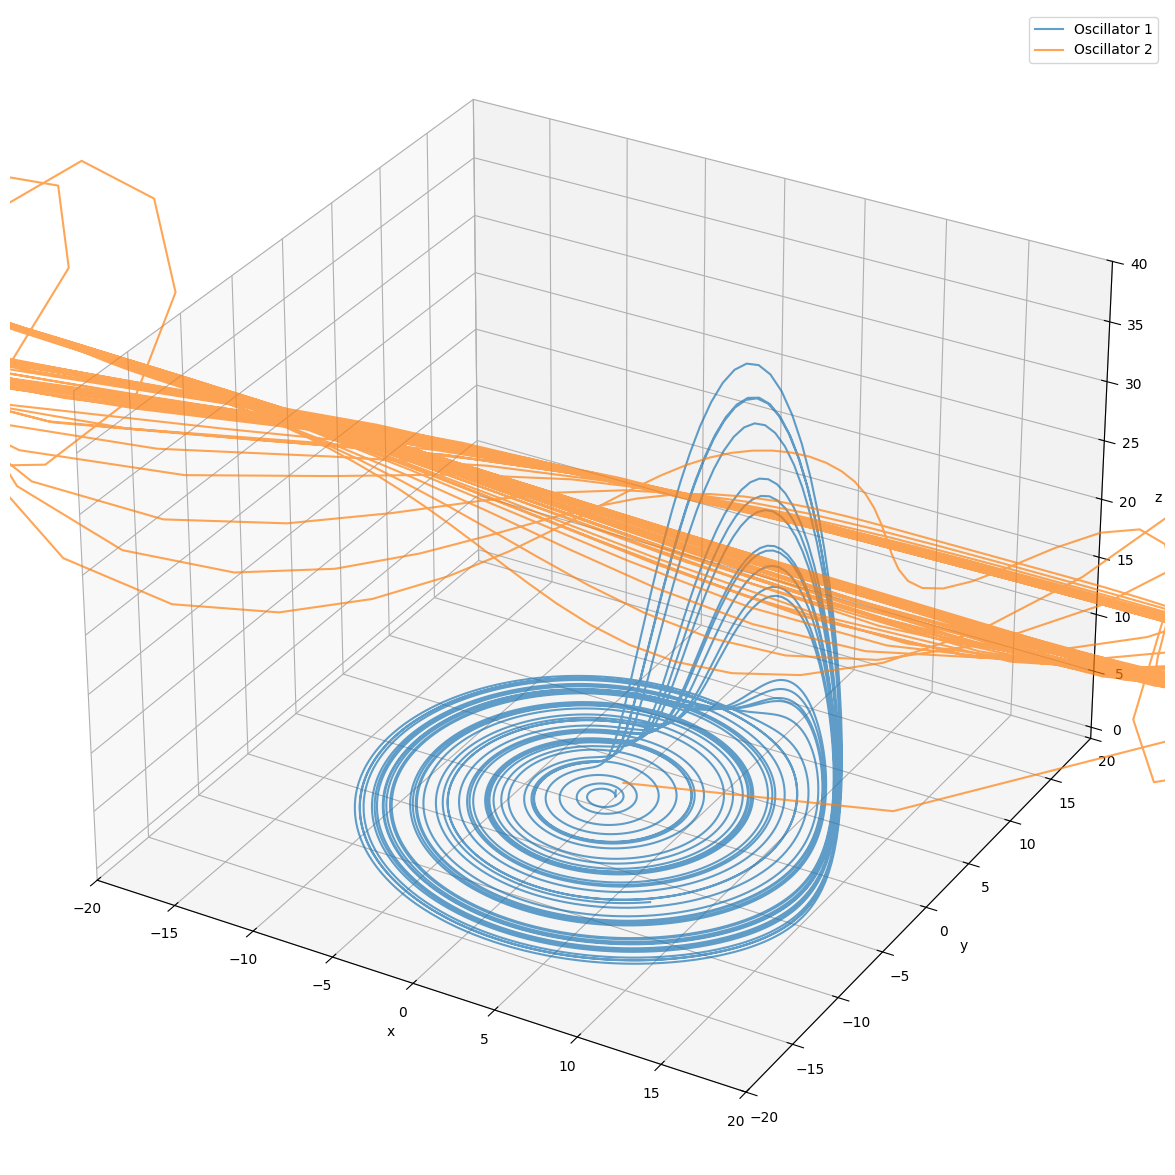

In [37]:
from mpl_toolkits.mplot3d import Axes3D

k1 = list(results.keys())[-1]

sol_c = results[k1]

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

fr = 0
to = -1

for k in range(0,2):
    x = sol_c.y[3*k, fr:to]
    y = sol_c.y[3*k + 1, fr:to]
    z = sol_c.y[3*k + 2, fr:to]
    ax.plot(x, y, z, alpha=0.7, label=f"Oscillator {k+1}")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.set_xlim(-20, 20)
ax.set_ylim(-20, 20)
ax.set_zlim(-1, 40)
ax.legend()
ax.set_title(f"")

plt.show()

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


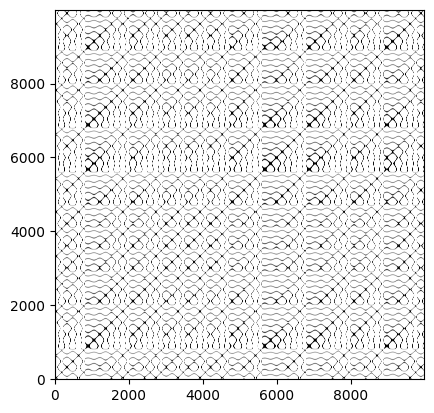

In [38]:
sol_rec = sol_c.y[:, 2000:12000]

RP = RecurrencePlot(sol_rec[3:6,:].T, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()

plt.imshow(RP, cmap="binary", origin="lower")

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


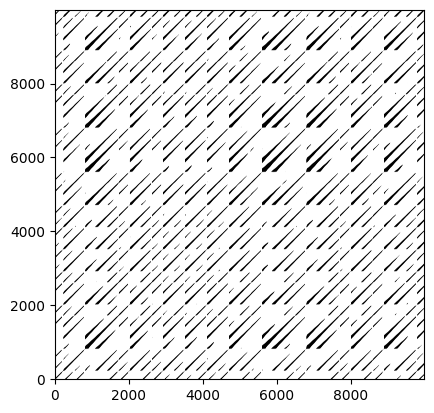

In [39]:
sol_rec = sol_c.y[:, 2000:12000]

RP = RecurrencePlot(sol_rec[0:3,:].T, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()

plt.imshow(RP, cmap="binary", origin="lower")

Calculating cross recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...


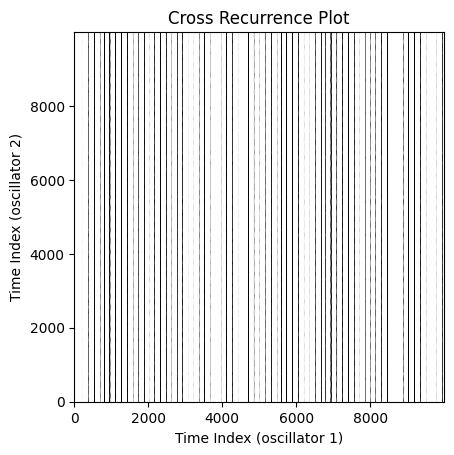

In [40]:
R_C = CrossRecurrencePlot(sol_rec[0:3,:].T, sol_rec[3:6,:].T, recurrence_rate=0.1, metric="euclidean")

RMat_C = R_C.recurrence_matrix()

plt.imshow(RMat_C, origin='lower', cmap='binary')
plt.title('Cross Recurrence Plot')
plt.xlabel('Time Index (oscillator 1)')
plt.ylabel('Time Index (oscillator 2)')
plt.show()

Calculating recurrence plot at fixed threshold...
Calculating the euclidean distance matrix...
Calculating joint recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating the euclidean distance matrix...


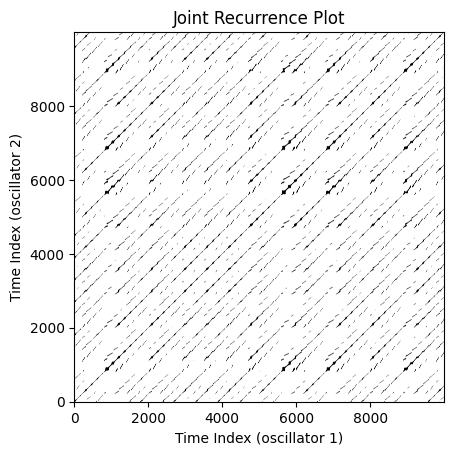

In [41]:
R_J = JointRecurrencePlot(sol_rec[0:3,:].T, sol_rec[3:6,:].T, recurrence_rate=(0.1,0.1), metric=("euclidean", "euclidean"))

RMat_J = R_J.recurrence_matrix()

plt.imshow(RMat_J, origin='lower', cmap='binary')
plt.title('Joint Recurrence Plot')
plt.xlabel('Time Index (oscillator 1)')
plt.ylabel('Time Index (oscillator 2)')
plt.show()

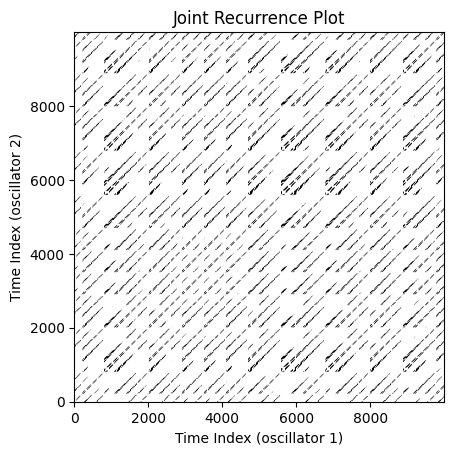

In [42]:
plt.imshow(RMat_J - RP, origin='lower', cmap='grey')
plt.title('Joint Recurrence Plot')
plt.xlabel('Time Index (oscillator 1)')
plt.ylabel('Time Index (oscillator 2)')
plt.show()

In [43]:
'''
import recurrence

l = 5000

cprs = []
stds = []

for i, e in enumerate(epss):
    sol_c = results[e]

    vals = []
    for start in range(2000, 10000, l):
        RX = RecurrencePlot(sol_c.y[0:3, start:start+l].T, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()
        RY = RecurrencePlot(sol_c.y[3:6, start:start+l].T, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()

        CPR = recurrence.cpr(RX, RY)
        vals.append(CPR)
    
    cprs.append(np.mean(vals))
    stds.append(np.std(vals))


plt.scatter(
    epss,
    cprs
)
plt.xscale("log")
plt.xlabel("Coupling Strength")
plt.ylabel("CPR")
'''

'\nimport recurrence\n\nl = 5000\n\ncprs = []\nstds = []\n\nfor i, e in enumerate(epss):\n    sol_c = results[e]\n\n    vals = []\n    for start in range(2000, 10000, l):\n        RX = RecurrencePlot(sol_c.y[0:3, start:start+l].T, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()\n        RY = RecurrencePlot(sol_c.y[3:6, start:start+l].T, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()\n\n        CPR = recurrence.cpr(RX, RY)\n        vals.append(CPR)\n    \n    cprs.append(np.mean(vals))\n    stds.append(np.std(vals))\n\n\nplt.scatter(\n    epss,\n    cprs\n)\nplt.xscale("log")\nplt.xlabel("Coupling Strength")\nplt.ylabel("CPR")\n'

In [44]:
class R_FAN(RecurrencePlot):
    """
    Returns a recurrence matrix based on a fixed number of nearest neighbors N
    """
    def rfan(self, Nn):
        distance = self.distance_matrix(metric="euclidean")
        N = distance.shape[0]

        R_mod = np.zeros((N, N))

        for i in range(N):
            dist = distance[i].copy()
            dist[i] = np.inf  
            idx = np.argsort(dist)[:Nn]
            R_mod[i, idx] = 1

        return R_mod

def jrp(oscillators, sol, Nn, mode="JPR", max_lag=None, plot=False, component=0, test_lag=0):

    if test_lag != 0:
        ts1, ts2 = sol.y[oscillators[0]:oscillators[0]+3, test_lag:].T, sol.y[oscillators[1]*3:oscillators[1]*3+3, :-test_lag].T
    else:
        ts1, ts2 = sol.y[oscillators[0]:oscillators[0]+3].T, sol.y[oscillators[1]*3:oscillators[1]*3+3].T

    N = ts1.shape[0]
    RR = Nn / N
    
    RF1 = R_FAN(ts1, recurrence_rate=0.05, metric="euclidean")
    Rx = RF1.rfan(Nn)
    RF2 = R_FAN(ts2, recurrence_rate=0.05, metric="euclidean")
    Ry = RF2.rfan(Nn)
    
    if mode == "simple":
        RRxy = np.sum(Rx * Ry) / (N*N)
        S = RRxy / RR

        return S
    
    elif mode == "JPR":
        if max_lag is None:
            raise ValueError("max_lag must be specified for JPR mode")

        s_tau = []
        taus = range(-max_lag, max_lag + 1)

        for tau in taus:

            if tau > 0:
                Rx_sub = Rx[:-tau, :-tau]
                Ry_sub = Ry[tau:, tau:]
            elif tau < 0:
                Rx_sub = Rx[-tau:, -tau:]
                Ry_sub = Ry[:tau, :tau]
            else:
                Rx_sub = Rx
                Ry_sub = Ry

            N_eff = Rx_sub.shape[0]

            RRxy_tau = np.sum(Rx_sub * Ry_sub) / (N_eff * N_eff)
            s_tau.append(RRxy_tau / RR)

        s_tau = np.array(s_tau)

        S_max = np.max(s_tau)
        tau_max = taus[np.argmax(s_tau)]

        JPR = (S_max - RR) / (1 - RR)

        if plot:
            fig, ax = plt.subplots(nrows=2, ncols=1, figsize=(30, 10))
            ax[0].plot(range(-max_lag, max_lag+1), s_tau)
            ax[1].plot(ts1[:,component], label="TS1", c="blue")
            ax[1].plot(ts2[:,component], label="TS2 Normal", ls="--", alpha=0.5, c="red")
            ax[1].plot(range(0-tau_max, ts2.shape[0]-tau_max), ts2[:,component], label="TS2 Lagged", c="red")
            plt.legend()
            plt.show()

        return {"tau": tau_max, "JPR": JPR}

    else:
        print("Choose either 'simple' or 'JPR' as mode")

In [45]:
'''
ks = []
jprs = []

for k, res in results.items():

    out = jrp(oscillators=(0,1), sol=res, Nn=1000, max_lag=100, plot=False, component=1)

    ks.append(k)
    jprs.append(out["JPR"])

plt.scatter(ks, jprs)
plt.xlabel("Coupling Strength (eps)")
plt.ylabel("Joint Probability Of Recurrences")
plt.xscale("log")
plt.show()
'''

'\nks = []\njprs = []\n\nfor k, res in results.items():\n\n    out = jrp(oscillators=(0,1), sol=res, Nn=1000, max_lag=100, plot=False, component=1)\n\n    ks.append(k)\n    jprs.append(out["JPR"])\n\nplt.scatter(ks, jprs)\nplt.xlabel("Coupling Strength (eps)")\nplt.ylabel("Joint Probability Of Recurrences")\nplt.xscale("log")\nplt.show()\n'

Download synched timeseries

In [46]:
sol_c = results[epss[-14]]

synch1 = sol_c.y[0:3, 7000:].T

synch2 = sol_c.y[3:6, 7000:].T

In [47]:
print(epss[-14])

47.14866363457394


In [48]:
import recurrence

RX_synch= RecurrencePlot(synch1, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()
RY_synch = RecurrencePlot(synch2, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()

print(recurrence.cpr(RX_synch, RY_synch))

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
0.8522435306073138


In [49]:
px_synch = recurrence.tau_recurrence(RX_synch)
py_synch = recurrence.tau_recurrence(RY_synch)

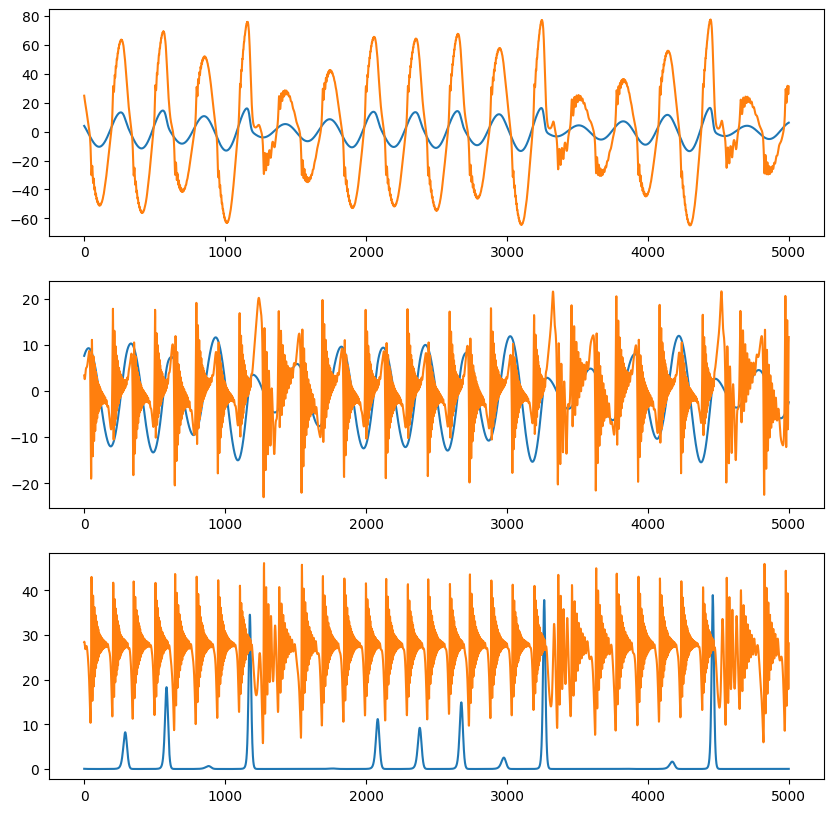

In [50]:
#Visualize
fig, axs = plt.subplots(3,1,figsize=(10, 10))

#Plot
axs[0].plot(synch1.T[0], label = '1')
axs[0].plot(synch2.T[0], label = '2')

axs[1].plot(synch1.T[1], label = '1')
axs[1].plot(synch2.T[1], label = '2')

axs[2].plot(synch1.T[2], label = '1')
axs[2].plot(synch2.T[2], label = '2')


plt.show()

In [51]:
import pandas as pd

# convert arrays into dataframe
DF1 = pd.DataFrame(synch1)
DF2 = pd.DataFrame(synch2)

# save the dataframe as a csv file
DF1.to_csv("GS_synch1.csv", index=False)
DF2.to_csv("GS_synch2.csv", index=False)

Download non-synched data

In [52]:
sol_c = results[epss[-25]]

nosynch1 = sol_c.y[0:3, 7000:].T

nosynch2 = sol_c.y[3:6, 7000:].T

In [53]:
print(epss[-25])

3.5564803062231287


In [54]:
import recurrence

RX_nosynch = RecurrencePlot(nosynch1, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()
RY_nosynch = RecurrencePlot(nosynch2, metric="euclidean", recurrence_rate=0.1).recurrence_matrix()

print(recurrence.cpr(RX_nosynch, RY_nosynch))

Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
Calculating recurrence plot at fixed recurrence rate...
Calculating the euclidean distance matrix...
0.10505983878714857


In [55]:
px_nosynch = recurrence.tau_recurrence(RX_nosynch)
py_nosynch = recurrence.tau_recurrence(RY_nosynch)

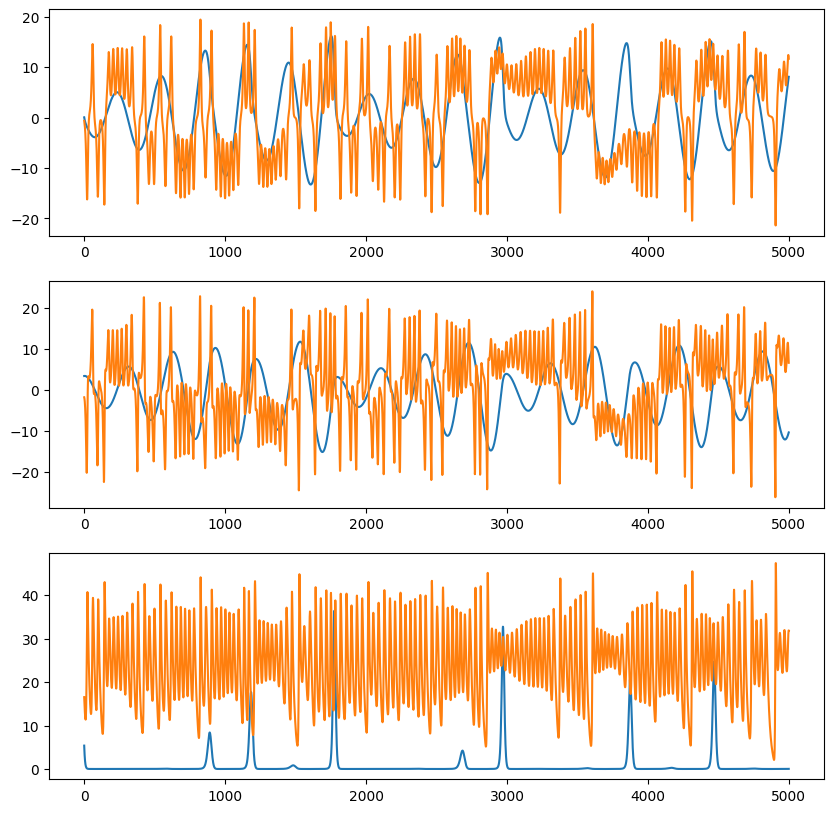

In [56]:
#Visualize
fig, axs = plt.subplots(3,1,figsize=(10, 10))

#Plot
axs[0].plot(nosynch1.T[0], label = '1')
axs[0].plot(nosynch2.T[0], label = '2')

axs[1].plot(nosynch1.T[1], label = '1')
axs[1].plot(nosynch2.T[1], label = '2')

axs[2].plot(nosynch1.T[2], label = '1')
axs[2].plot(nosynch2.T[2], label = '2')


plt.show()

In [57]:
import pandas as pd

# convert arrays into dataframe
DF1 = pd.DataFrame(nosynch1)
DF2 = pd.DataFrame(nosynch2)

# save the dataframe as a csv file
DF1.to_csv("GS_nosynch1.csv", index=False)
DF2.to_csv("GS_nosynch2.csv", index=False)

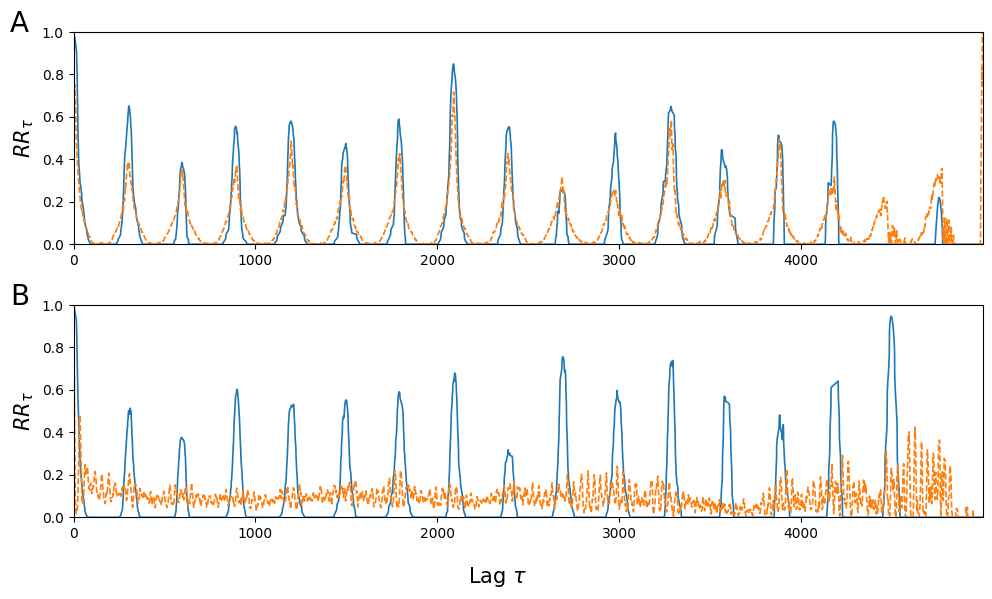

In [58]:
import string

# Visualize
fig, axs = plt.subplots(2,1,figsize=(10, 6))

taus = np.arange(0,len(px_nosynch))

axs[0].plot(taus, px_synch, linewidth = 1.2)
axs[0].plot(taus, py_synch, linestyle='dashed', linewidth = 1.2)

axs[0].margins(0) 

#axs.set_xticks(np.arange(0,len(tau_rr_embed),50))

axs[0].set_ylabel(r'$RR_{\tau}$', fontsize = 15)
axs[0].text(-0.07, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

# Plot each graph, and manually set the y tick values
axs[1].plot(taus, px_nosynch, linewidth = 1.2)
axs[1].plot(taus, py_nosynch, linestyle='dashed', linewidth = 1.2)

axs[1].margins(0) 

#axs.set_xticks(np.arange(0,len(tau_rr_embed),50))

axs[1].set_ylabel(r'$RR_{\tau}$', fontsize = 15)
axs[1].text(-0.07, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)
#axs.set_title('Embedded time series')


fig.supxlabel(r'Lag $\tau$', fontsize = 15)

plt.tight_layout()

plt.show()

fig.savefig('RRT_GS.png')

In [59]:
#Recurrence matrix updated version
def recurrence_matrix_fan(timeseries, RR, transpose = False):
    nn_i = int(RR*len(timeseries))

    if timeseries.ndim == 1:
        r_matrix = []
        for i in range(len(timeseries)):
            current_row = []
            for j in range(len(timeseries)):
                current_value = np.abs(timeseries[i] - timeseries[j])
                current_row.append(current_value)

            current_row = np.array(current_row)
            recs_i = np.argsort(current_row)[:nn_i]
            current_row[:] = 0
            current_row[recs_i] = 1
        
            r_matrix.append(current_row)
    
        return np.array(r_matrix)
    
    else: 
        '''
        We will use euclidean distance in order to estimate neighbours.
        '''
        #Create distance matrix
        if transpose == True:
            timeseries = timeseries.T

        d_matrix = squareform(pdist(timeseries, metric = 'euclidean'))

        for i in range(d_matrix.shape[0]):
            current_row = d_matrix[i]
            recs_i = np.argsort(current_row)[:nn_i]
            current_row[:] = 0
            current_row[recs_i] = 1

            d_matrix[i] = current_row   

        return d_matrix 

In [60]:
import recurrence

RX_nosynch = recurrence_matrix_fan(nosynch1, RR=0.1)
RY_nosynch = recurrence_matrix_fan(nosynch2, RR=0.1)

print(recurrence.cpr(RX_nosynch, RY_nosynch))

0.10244618048530511


In [61]:
px_nosynch = recurrence.tau_recurrence(RX_nosynch)
py_nosynch = recurrence.tau_recurrence(RY_nosynch)

In [62]:
RX_synch = recurrence_matrix_fan(synch1, RR=0.1)
RY_synch = recurrence_matrix_fan(synch2, RR=0.1)

In [63]:
px_synch = recurrence.tau_recurrence(RX_synch)
py_synch = recurrence.tau_recurrence(RY_synch)

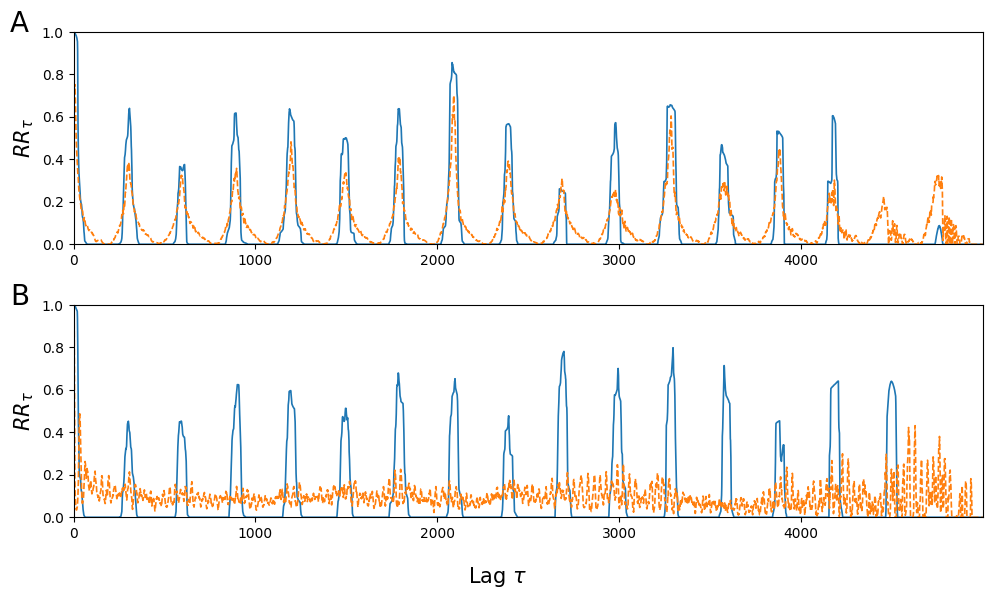

In [64]:
# Visualize
fig, axs = plt.subplots(2,1,figsize=(10, 6))

taus = np.arange(0,len(px_nosynch))

axs[0].plot(taus, px_synch, linewidth = 1.2)
axs[0].plot(taus, py_synch, linestyle='dashed', linewidth = 1.2)

axs[0].margins(0) 

#axs.set_xticks(np.arange(0,len(tau_rr_embed),50))

axs[0].set_ylabel(r'$RR_{\tau}$', fontsize = 15)
axs[0].text(-0.07, 1, string.ascii_uppercase[0], transform=axs[0].transAxes, 
            size=20)

# Plot each graph, and manually set the y tick values
axs[1].plot(taus, px_nosynch, linewidth = 1.2)
axs[1].plot(taus, py_nosynch, linestyle='dashed', linewidth = 1.2)

axs[1].margins(0) 

#axs.set_xticks(np.arange(0,len(tau_rr_embed),50))

axs[1].set_ylabel(r'$RR_{\tau}$', fontsize = 15)
axs[1].text(-0.07, 1, string.ascii_uppercase[1], transform=axs[1].transAxes, 
            size=20)
#axs.set_title('Embedded time series')


fig.supxlabel(r'Lag $\tau$', fontsize = 15)

plt.tight_layout()

plt.show()

fig.savefig('RRT_GSFAN.png')